# Polarimetric signatures

- Open the San Francisco ALOS-1 scattering matrix.
- Convert `S` to `T3`.
- Apply 4 × 1 multilooking.
- Apply a 5 × 5 boxcar filter.
- Compute and plot polarimetric signatures for three example pixels.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from dask.diagnostics import ProgressBar

from polsarpro.io import open_netcdf_beam
from polsarpro.polarisation import (
    plot_polarimetric_signature,
    polarimetric_signature,
)
from polsarpro.util import S_to_T3, boxcar, multilook, pauli_rgb

input_file = Path("/data/psp/test_files/SAN_FRANCISCO_ALOS1_slc.nc")

In [2]:
S = open_netcdf_beam(input_file)
print(S)

<xarray.Dataset> Size: 736MB
Dimensions:  (y: 18432, x: 1248)
Coordinates:
  * y        (y) int64 147kB 0 1 2 3 4 5 ... 18426 18427 18428 18429 18430 18431
  * x        (x) int64 10kB 0 1 2 3 4 5 6 ... 1241 1242 1243 1244 1245 1246 1247
Data variables:
    hh       (y, x) complex64 184MB dask.array<chunksize=(624, 576), meta=np.ndarray>
    hv       (y, x) complex64 184MB dask.array<chunksize=(624, 576), meta=np.ndarray>
    vh       (y, x) complex64 184MB dask.array<chunksize=(624, 576), meta=np.ndarray>
    vv       (y, x) complex64 184MB dask.array<chunksize=(624, 576), meta=np.ndarray>
Attributes:
    poltype:      S
    description:  Scattering matrix


## Prepare the coherency matrix

The row positions used below refer to the T3 matrix after 4 × 1 multilooking.

In [3]:
T3 = S_to_T3(S)
T3 = multilook(T3, dim_az=4, dim_rg=1)
T3 = boxcar(T3, dim_az=5, dim_rg=5)
print(T3)

<xarray.Dataset> Size: 207MB
Dimensions:  (y: 4608, x: 1248)
Coordinates:
  * y        (y) float64 37kB 1.5 5.5 9.5 13.5 ... 1.842e+04 1.843e+04 1.843e+04
  * x        (x) float64 10kB 0.0 1.0 2.0 3.0 ... 1.245e+03 1.246e+03 1.247e+03
Data variables:
    m11      (y, x) float32 23MB dask.array<chunksize=(156, 576), meta=np.ndarray>
    m22      (y, x) float32 23MB dask.array<chunksize=(156, 576), meta=np.ndarray>
    m33      (y, x) float32 23MB dask.array<chunksize=(156, 576), meta=np.ndarray>
    m12      (y, x) complex64 46MB dask.array<chunksize=(156, 576), meta=np.ndarray>
    m13      (y, x) complex64 46MB dask.array<chunksize=(156, 576), meta=np.ndarray>
    m23      (y, x) complex64 46MB dask.array<chunksize=(156, 576), meta=np.ndarray>
Attributes:
    poltype:      T3
    description:  Coherency matrix (3x3)


## Compute four signatures

Each `(row, col)` pair is an integer pixel position in the filtered T3 matrix. The three selected points lie in areas with visibly different responses in the Pauli RGB image.

In [4]:
points = {
    "Point A": (2100, 100),
    "Point B": (2340, 700),
    "Point C": (3900, 300),
}

signatures = {}
with ProgressBar():
    for name, (row, col) in points.items():
        signatures[name] = polarimetric_signature(T3, row=row, col=col)

[########################################] | 100% Completed | 724.38 ms
[########################################] | 100% Completed | 825.10 ms
[########################################] | 100% Completed | 721.40 ms


## Inspect the selected pixels

The Pauli RGB image shows where the three example pixels lie in the filtered T3 matrix.

[########################################] | 100% Completed | 8.47 sms


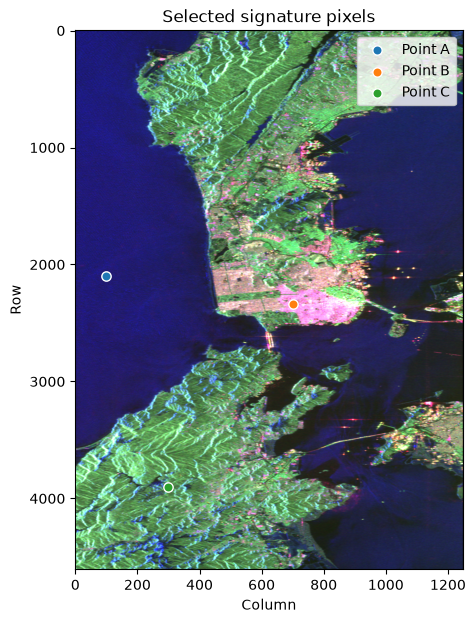

In [5]:
with ProgressBar():
    pauli = pauli_rgb(T3).compute()

figure, axis = plt.subplots(figsize=(5, 7))
axis.imshow(pauli.transpose("y", "x", "band").values, origin="upper", aspect="auto")
for name, (row, col) in points.items():
    axis.scatter(col, row, s=45, edgecolor="white", label=name)
axis.set(title="Selected signature pixels", xlabel="Column", ylabel="Row")
axis.legend()
plt.show()

## Plot the signatures

`azimuth_angle` and `elevation_angle` control only the 3D camera. They are independent of the SAR image coordinates. The returned figure and axes can be edited with Matplotlib or saved with `figure.savefig(...)`.

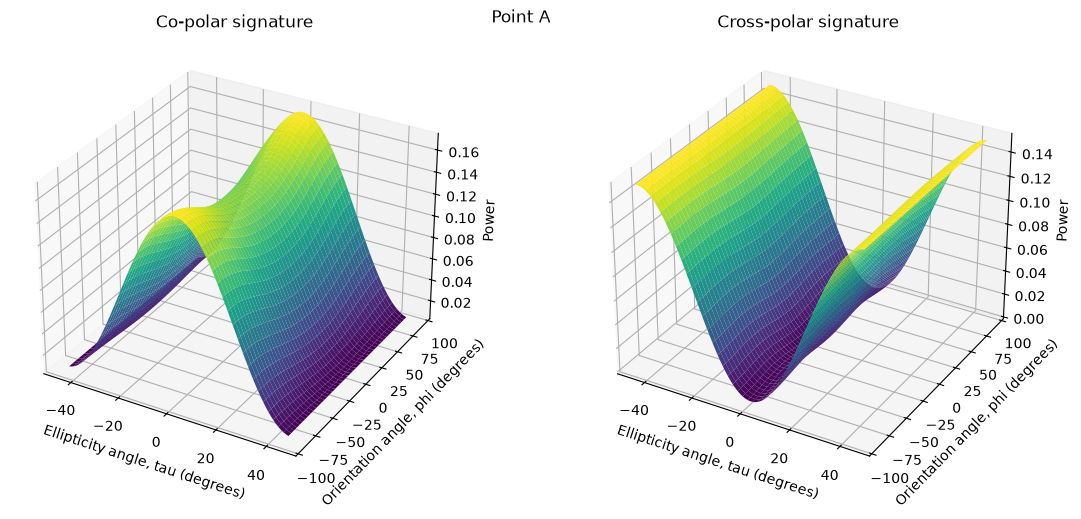

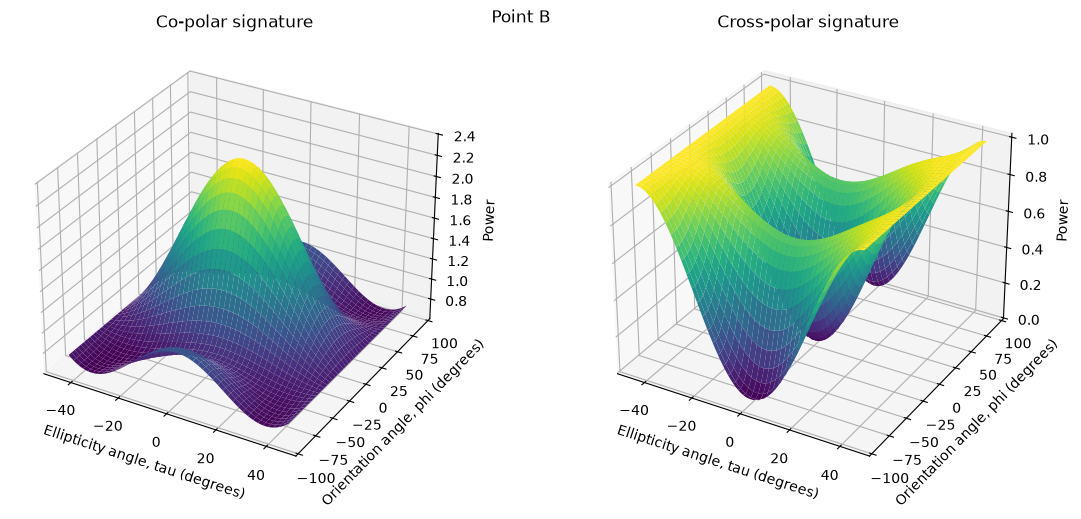

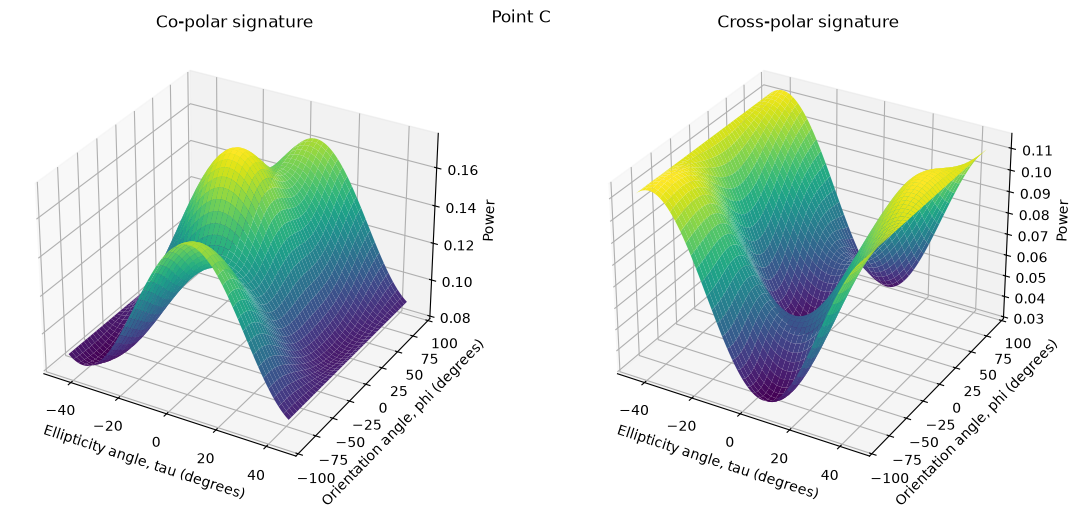

In [6]:
figures = {}
for name, signature in signatures.items():
    figure, axes = plot_polarimetric_signature(
        signature, azimuth_angle=-60, elevation_angle=30
    )
    figure.suptitle(name)
    figures[name] = (figure, axes)
plt.show()

For publication output, save any returned figure as PNG or PDF:

```python
figure, axes = figures["Point B"]
figure.savefig("point-b-signature.png", dpi=300, bbox_inches="tight")
figure.savefig("point-b-signature.pdf", bbox_inches="tight")
```